###  ASSIGNMENT 5

In [ ]:
# import/load data

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# The file has no header, so we specify header=None
df = pd.read_csv('ML_HW_Data_CellDNA.csv', header=None)

In [ ]:
# step 1 is the pre processing of data 

# Extract features (X) - all columns except the last one
X = df.iloc[:, :-1].values

# Extract target (y) - the last column
y_raw = df.iloc[:, -1].values

# convert target to strict binary (0s and 1s)
# Any value greater than 0 becomes 1, 0 remains 0
y = np.where(y_raw > 0, 1, 0)

# Standardize the features before applying Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# Step 2 an 3: Cross Validation Setup and Lasso 

# KFold to meet HW requirement of 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Generate a log array of C values to test
# sweep from strong penalty (10^-4) to weak penalty (10^1)
C_values = np.logspace(-4, 1, 100)

coefs_path = []
optimal_C = None
optimal_thetas = None
optimal_indices = None

In [4]:
# create for loop for C values to find exactly 3 non-zero predictors
for c in C_values:
    clf = LogisticRegression(penalty='l1', solver='liblinear', C=c, random_state=42)
    clf.fit(X_scaled, y)
    
    # store coefs for plotting later
    coefs_path.append(clf.coef_[0])
    
    # count how many non-zero predictors remain
    non_zero_count = np.count_nonzero(clf.coef_[0])
    
    # capture the state when 3 predictors are non-zero
    if non_zero_count == 3 and optimal_C is None:
        optimal_C = c
        optimal_thetas = clf.coef_[0]
        optimal_indices = np.where(optimal_thetas != 0)[0]

/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

In [7]:
# Answers for Q3, Q4, and Q5

print(f"Q4 Answer: ideal C value to isolate 3 predictors is: {optimal_C:.6f}")

print(f"\nQ3Answer: top 3 predictors are located at zero-indexed columns:")
print(optimal_indices)

print(f"\nQ5 Answer: corresponding non-zero Theta values are:")
for idx, theta in zip(optimal_indices, optimal_thetas[optimal_indices]):
    print(f"Predictor Index {idx}: Theta = {theta:.6f}")

# --- Step 5: 10-Fold CV Evaluation ---
from sklearn.model_selection import cross_validate

# 10-Fold CV Evaluation on the isolated model using rigorous metrics
final_clf = LogisticRegression(penalty='l1', solver='liblinear', C=optimal_C, random_state=42)

# def the eval hierarchy
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

# Run the rigorous cross-validation
cv_results = cross_validate(final_clf, X_scaled, y, cv=kf, scoring=scoring_metrics)

print("\n--- Rigorous 10-Fold CV Metrics (Mean) ---")
print(f"Accuracy:  {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
print(f"Recall:    {np.mean(cv_results['test_recall']):.4f}")
print(f"F1-Score:  {np.mean(cv_results['test_f1']):.4f}")

Q4 Answer: ideal C value to isolate 3 predictors is: 0.084975

Q3Answer: top 3 predictors are located at zero-indexed columns:
[3 4 6]

Q5 Answer: corresponding non-zero Theta values are:
Predictor Index 3: Theta = 2.330815
Predictor Index 4: Theta = -1.913448
Predictor Index 6: Theta = -0.002164

--- Rigorous 10-Fold CV Metrics (Mean) ---
Accuracy:  0.9137
Precision: 0.8006
Recall:    0.6333
F1-Score:  0.6993


/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/karanpatel/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

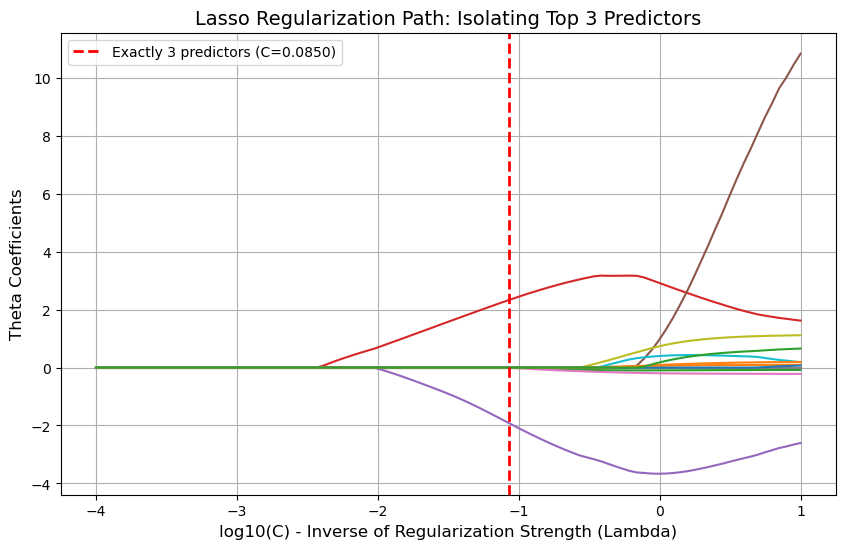

In [8]:

# Step 4: Generate the Lasso Plot (HW Q2)
plt.figure(figsize=(10, 6))

# plot the log10 of C on the X-axis 
plt.plot(np.log10(C_values), coefs_path)

# vertical line where the 3 predictors are found
plt.axvline(np.log10(optimal_C), color='red', linestyle='--', linewidth=2, 
            label=f'Exactly 3 predictors (C={optimal_C:.4f})')

# labeling 
plt.xlabel('log10(C) - Inverse of Regularization Strength (Lambda)', fontsize=12)
plt.ylabel('Theta Coefficients', fontsize=12)
plt.title('Lasso Regularization Path: Isolating Top 3 Predictors', fontsize=14)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()